# OIBSIP INTERNSHIP TASK NO 2
**Car Price Prediction with Machine Learning BY WARID ALI**

Saving car data.csv to car data (2).csv
Shape: (301, 9)

Missing values: 0

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


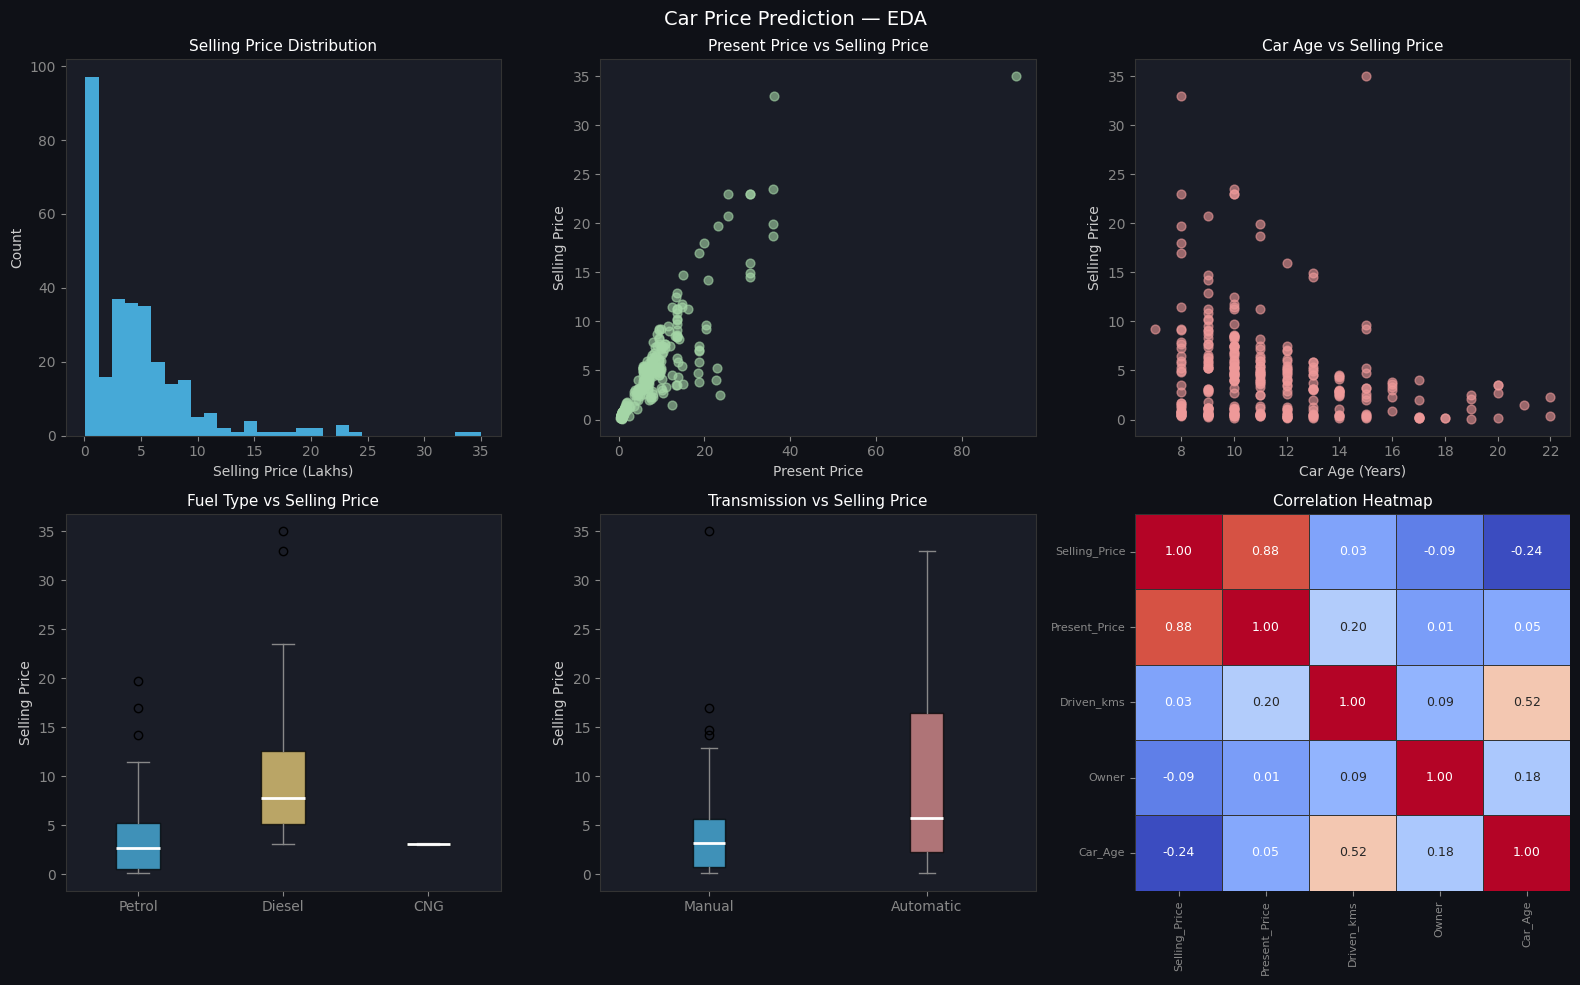


Train size: (240, 7) | Test size: (61, 7)

Model                       R² Score        MAE       RMSE
----------------------------------------------------------
Linear Regression             0.8467     1.2219     1.8792
Decision Tree                 0.9106     0.8484     1.4353
Random Forest                 0.9593     0.6389     0.9686
Gradient Boosting             0.9656     0.5556     0.8907

 Best Model: Gradient Boosting (R² = 0.9656)


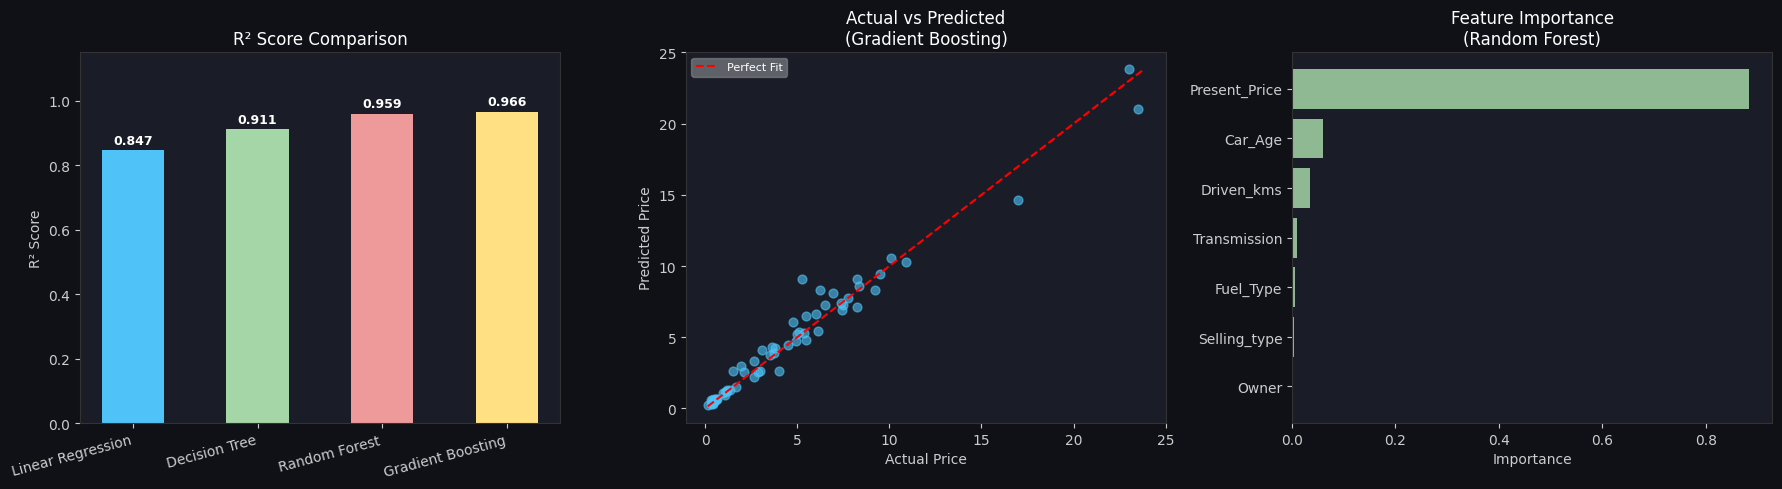


Sample Predictions — Gradient Boosting:


,Actual,Predicted,Difference
0,0.35,0.61,0.26
1,10.11,10.60,0.49
2,4.95,4.75,-0.20
3,0.15,0.26,0.11
4,6.95,8.09,1.14
5,7.45,6.91,-0.54
6,1.10,1.14,0.04
7,0.50,0.66,0.16
8,0.45,0.49,0.04
9,6.00,6.64,0.64


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD DATA
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('car data (1).csv')

print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nFirst 5 rows:")
display(df.head())

#  2. FEATURE ENGINEERING
df['Car_Age'] = 2025 - df['Year']
df.drop(columns=['Year', 'Car_Name'], inplace=True)

#  3. EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#0f1117')
axes = axes.flatten()

# Plot 1 — Selling Price Distribution
axes[0].hist(df['Selling_Price'].values, bins=30,
             color='#4fc3f7', edgecolor='none', alpha=0.85)
axes[0].set_title('Selling Price Distribution', color='white', fontsize=11)
axes[0].set_xlabel('Selling Price (Lakhs)', color='#ccc')
axes[0].set_ylabel('Count', color='#ccc')

# Plot 2 — Present Price vs Selling Price
axes[1].scatter(df['Present_Price'].values, df['Selling_Price'].values,
                color='#a5d6a7', alpha=0.6, s=40)
axes[1].set_title('Present Price vs Selling Price', color='white', fontsize=11)
axes[1].set_xlabel('Present Price', color='#ccc')
axes[1].set_ylabel('Selling Price', color='#ccc')

# Plot 3 — Car Age vs Selling Price
axes[2].scatter(df['Car_Age'].values, df['Selling_Price'].values,
                color='#ef9a9a', alpha=0.6, s=40)
axes[2].set_title('Car Age vs Selling Price', color='white', fontsize=11)
axes[2].set_xlabel('Car Age (Years)', color='#ccc')
axes[2].set_ylabel('Selling Price', color='#ccc')

# Plot 4 — Fuel Type Box Plot
fuel_types = ['Petrol', 'Diesel', 'CNG']
fuel_groups = [df[df['Fuel_Type'] == f]['Selling_Price'].values for f in fuel_types]
bp1 = axes[3].boxplot(fuel_groups, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp1['boxes'], ['#4fc3f7', '#ffe082', '#a5d6a7']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp1[element]:
        item.set_color('#888')
axes[3].set_xticks([1, 2, 3])
axes[3].set_xticklabels(fuel_types, color='#ccc')
axes[3].set_title('Fuel Type vs Selling Price', color='white', fontsize=11)
axes[3].set_ylabel('Selling Price', color='#ccc')

# Plot 5 — Transmission Box Plot
trans_types = ['Manual', 'Automatic']
trans_groups = [df[df['Transmission'] == t]['Selling_Price'].values for t in trans_types]
bp2 = axes[4].boxplot(trans_groups, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp2['boxes'], ['#4fc3f7', '#ef9a9a']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp2[element]:
        item.set_color('#888')
axes[4].set_xticks([1, 2])
axes[4].set_xticklabels(trans_types, color='#ccc')
axes[4].set_title('Transmission vs Selling Price', color='white', fontsize=11)
axes[4].set_ylabel('Selling Price', color='#ccc')

# Plot 6 — Correlation Heatmap
num_df = df.select_dtypes(include='number')
corr = num_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[5], cbar=False, annot_kws={'size': 9},
            linewidths=0.5, linecolor='#333')
axes[5].set_title('Correlation Heatmap', color='white', fontsize=11)
axes[5].tick_params(colors='#ccc', labelsize=8)

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#888')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

fig.suptitle('Car Price Prediction — EDA', color='white', fontsize=14)
plt.tight_layout()
plt.show()

#  4. PREPROCESSING
le = LabelEncoder()
for col in ['Fuel_Type', 'Selling_type', 'Transmission']:
    df[col] = le.fit_transform(df[col])

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nTrain size: {X_train.shape} | Test size: {X_test.shape}")

#  5. TRAIN MODELS
models = {
    'Linear Regression':  LinearRegression(),
    'Decision Tree':      DecisionTreeRegressor(random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
print(f"\n{'Model':<25} {'R² Score':>10} {'MAE':>10} {'RMSE':>10}")
print("-" * 58)
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {'model': model, 'preds': preds, 'r2': r2, 'mae': mae, 'rmse': rmse}
    print(f"{name:<25} {r2:>10.4f} {mae:>10.4f} {rmse:>10.4f}")

best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]
print(f"\n Best Model: {best_name} (R² = {best['r2']:.4f})")

# 6. RESULTS PLOTS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')

# R² Bar Chart
names = list(results.keys())
r2s   = [results[n]['r2'] for n in names]
bars  = axes[0].bar(names, r2s,
                    color=['#4fc3f7', '#a5d6a7', '#ef9a9a', '#ffe082'],
                    width=0.5, edgecolor='none')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('R² Score Comparison', color='white', fontsize=12)
axes[0].set_ylabel('R² Score', color='#ccc')
axes[0].set_xticklabels(names, rotation=15, ha='right', color='#ccc')
for bar, r2 in zip(bars, r2s):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{r2:.3f}', ha='center', color='white',
                 fontsize=9, fontweight='bold')

# Actual vs Predicted
axes[1].scatter(y_test.values, best['preds'],
                color='#4fc3f7', alpha=0.6, s=40)
min_val = min(y_test.min(), best['preds'].min())
max_val = max(y_test.max(), best['preds'].max())
axes[1].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1.5, label='Perfect Fit')
axes[1].set_title(f'Actual vs Predicted\n({best_name})', color='white', fontsize=12)
axes[1].set_xlabel('Actual Price', color='#ccc')
axes[1].set_ylabel('Predicted Price', color='#ccc')
axes[1].legend(fontsize=8, framealpha=0.3, labelcolor='white')

# Feature Importance
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
axes[2].barh(importances.index, importances.values,
             color='#a5d6a7', edgecolor='none', alpha=0.85)
axes[2].set_title('Feature Importance\n(Random Forest)', color='white', fontsize=12)
axes[2].set_xlabel('Importance', color='#ccc')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#ccc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

plt.tight_layout()
plt.show()

#  7. SAMPLE PREDICTIONS
print(f"\nSample Predictions — {best_name}:")
sample = pd.DataFrame({
    'Actual':    y_test.values[:10],
    'Predicted': best['preds'][:10].round(2),
})
sample['Difference'] = (sample['Predicted'] - sample['Actual']).round(2)
display(sample.round(2))